# Gaussian Mixture Model (GMM) Clustering

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
import time  # Added for execution time tracking

In [ ]:
# Load the dataset
X = pd.read_csv('finalclusteringdataset.csv')
start_time = time.time()  # Start timing

   trip_frequency  average_booking_value  destination_diversity  \
0       -0.932410              -0.670922               0.799784   
1       -0.464474               0.027663               0.799784   
2       -0.464474              -0.506637              -1.186431   
3        0.003461              -0.404627              -1.186431   
4       -0.464474              -0.250067               0.799784   

   session_duration  search_behavior  
0          0.238273        -1.231300  
1         -0.216633         1.220781  
2         -0.460439        -0.005260  
3         -1.011564         1.220781  
4          0.550754        -0.005260  
(100002, 5)


In [18]:
print('\n=== Testing Different Covariance Types ===')
covariance_types = ['full', 'tied', 'diag', 'spherical']
best_cov = None
best_bic = np.inf

# Use sample for faster testing
sample_size = min(20000, len(X))
X_sample = X.sample(n=sample_size, random_state=42)

for cov_type in covariance_types:
    print(f'Testing {cov_type}...')
    try:
        # Test with n_components=3 (temporary)
        gmm_temp = GaussianMixture(n_components=3, covariance_type=cov_type, 
                                   random_state=42, n_init=3)
        gmm_temp.fit(X_sample)
        bic = gmm_temp.bic(X_sample)
        print(f'  {cov_type.capitalize()}: BIC = {bic:.2f}')
        
        if bic < best_bic:
            best_bic = bic
            best_cov = cov_type
    except Exception as e:
        print(f'  {cov_type.capitalize()}: Failed - {e}')

print(f'\n✓ Auto-selected covariance type: {best_cov} (BIC: {best_bic:.2f})')


=== Testing Different Covariance Types ===
Testing full...
  Full: BIC = 197210.12
Testing tied...
  Tied: BIC = 276980.53
Testing diag...
  Diag: BIC = 196932.73
Testing spherical...
  Spherical: BIC = 283048.06

✓ Auto-selected covariance type: diag (BIC: 196932.73)


In [19]:
print('\n=== Finding Optimal Number of Components ===')
n_components_range = range(2, 11)
bic_scores = []
aic_scores = []
silhouette_scores = []

for n in n_components_range:
    print(f'Testing n_components={n}...')
    
    gmm = GaussianMixture(n_components=n, covariance_type=best_cov, 
                          random_state=42, n_init=5, max_iter=200)
    gmm.fit(X_sample)
    
    # BIC and AIC
    bic = gmm.bic(X_sample)
    aic = gmm.aic(X_sample)
    bic_scores.append(bic)
    aic_scores.append(aic)
    
    # Silhouette score
    labels = gmm.predict(X_sample)
    sil = silhouette_score(X_sample, labels)
    silhouette_scores.append(sil)
    
    print(f'  BIC: {bic:.2f}, AIC: {aic:.2f}, Silhouette: {sil:.4f}')

# Auto-select optimal n_components
# Lower BIC is better, higher silhouette is better
optimal_n_bic = n_components_range[np.argmin(bic_scores)]
optimal_n_sil = n_components_range[np.argmax(silhouette_scores)]

print(f'\n✓ Optimal by BIC: {optimal_n_bic}')
print(f'✓ Optimal by Silhouette: {optimal_n_sil}')

# Use BIC as primary criterion (more reliable for GMM)
optimal_n = optimal_n_bic
print(f'\n✓ Final selection: {optimal_n} components')


=== Finding Optimal Number of Components ===
Testing n_components=2...
  BIC: 280674.62, AIC: 280508.65, Silhouette: 0.1639
Testing n_components=3...
  BIC: 194360.51, AIC: 194107.60, Silhouette: 0.1643
Testing n_components=4...
  BIC: 193210.70, AIC: 192870.85, Silhouette: 0.1461
Testing n_components=5...
  BIC: 192074.98, AIC: 191648.19, Silhouette: 0.1387
Testing n_components=6...
  BIC: 29494.78, AIC: 28981.05, Silhouette: 0.0395
Testing n_components=7...
  BIC: 8521.02, AIC: 7920.36, Silhouette: 0.0510
Testing n_components=8...
  BIC: 6544.99, AIC: 5857.38, Silhouette: 0.0606
Testing n_components=9...
  BIC: 13035.24, AIC: 12260.70, Silhouette: 0.0393
Testing n_components=10...
  BIC: 9612.73, AIC: 8751.25, Silhouette: -0.0035

✓ Optimal by BIC: 8
✓ Optimal by Silhouette: 3

✓ Final selection: 8 components


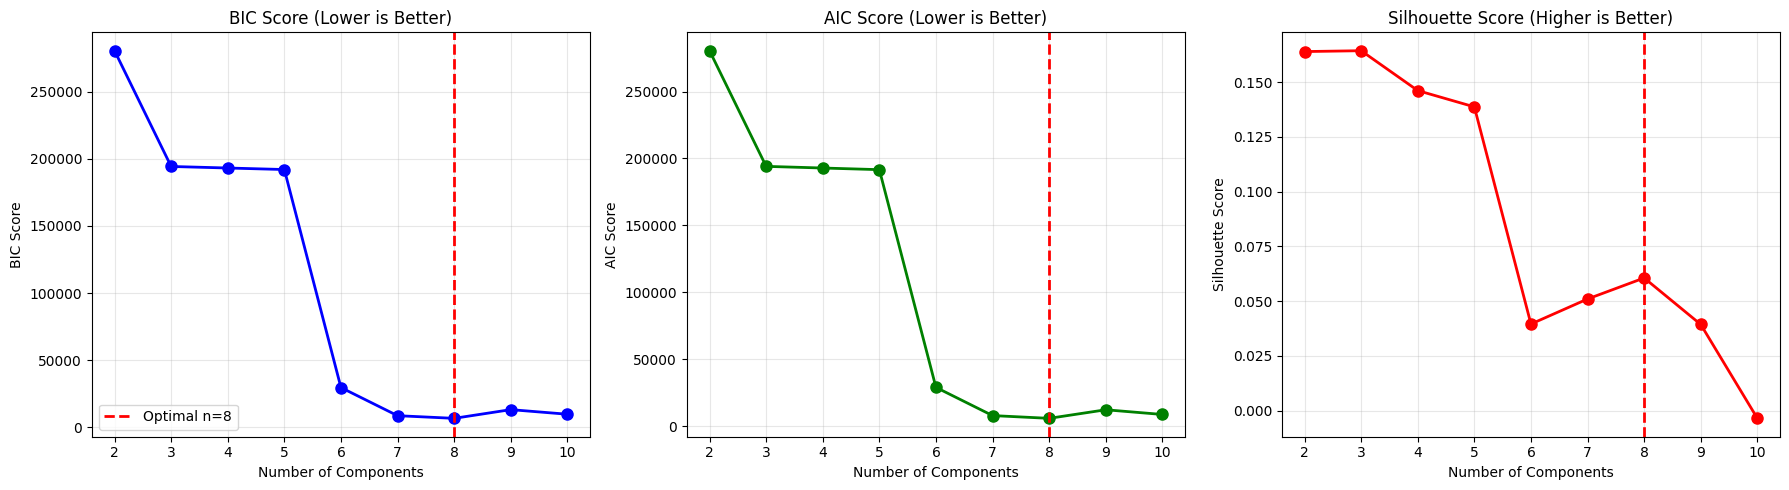

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# BIC Plot
axes[0].plot(n_components_range, bic_scores, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=optimal_n, color='red', linestyle='--', linewidth=2, 
                label=f'Optimal n={optimal_n}')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('BIC Score')
axes[0].set_title('BIC Score (Lower is Better)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# AIC Plot
axes[1].plot(n_components_range, aic_scores, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=optimal_n, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('AIC Score')
axes[1].set_title('AIC Score (Lower is Better)')
axes[1].grid(True, alpha=0.3)

# Silhouette Plot
axes[2].plot(n_components_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[2].axvline(x=optimal_n, color='red', linestyle='--', linewidth=2)
axes[2].set_xlabel('Number of Components')
axes[2].set_ylabel('Silhouette Score')
axes[2].set_title('Silhouette Score (Higher is Better)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
print('\n=== Training Final GMM Model ===')
print(f'Components: {optimal_n}')
print(f'Covariance type: {best_cov}')

# Train on FULL dataset (GMM is faster than hierarchical!)
gmm_final = GaussianMixture(n_components=optimal_n, 
                            covariance_type=best_cov,
                            random_state=42, 
                            n_init=10,
                            max_iter=300,
                            verbose=1)

print('Fitting GMM on full 100k dataset...')
gmm_final.fit(X)
print('✓ Model trained')

# Predict clusters
cluster_labels = gmm_final.predict(X)
print('✓ Cluster labels assigned')


=== Training Final GMM Model ===
Components: 8
Covariance type: diag
Fitting GMM on full 100k dataset...
Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
  Iteration 40
Initialization converged.
Initialization 1
Initialization converged.
Initialization 2
  Iteration 10
Initialization converged.
Initialization 3
  Iteration 10
  Iteration 20
  Iteration 30
Initialization converged.
Initialization 4
  Iteration 10
Initialization converged.
Initialization 5
  Iteration 10
Initialization converged.
Initialization 6
  Iteration 10
  Iteration 20
Initialization converged.
Initialization 7
  Iteration 10
  Iteration 20
Initialization converged.
Initialization 8
Initialization converged.
Initialization 9
  Iteration 10
Initialization converged.
✓ Model trained
✓ Cluster labels assigned


In [22]:
print('\n=== Final Model Evaluation ===')

# Use sample for silhouette (faster)
sample_idx = np.random.choice(len(X), size=min(10000, len(X)), replace=False)
final_sil = silhouette_score(X.iloc[sample_idx], cluster_labels[sample_idx])
final_db = davies_bouldin_score(X, cluster_labels)
final_bic = gmm_final.bic(X)
final_aic = gmm_final.aic(X)

print(f'Number of components: {optimal_n}')
print(f'Covariance type: {best_cov}')
print(f'Silhouette Score: {final_sil:.4f}')
print(f'Davies-Bouldin Score: {final_db:.4f}')
print(f'BIC Score: {final_bic:.2f}')
print(f'AIC Score: {final_aic:.2f}')
print(f'Converged: {gmm_final.converged_}')
print(f'Iterations: {gmm_final.n_iter_}')


=== Final Model Evaluation ===
Number of components: 8
Covariance type: diag
Silhouette Score: 0.0381
Davies-Bouldin Score: 2.8503
BIC Score: 84304.69
AIC Score: 83477.06
Converged: True
Iterations: 41



=== Creating visualizations ===


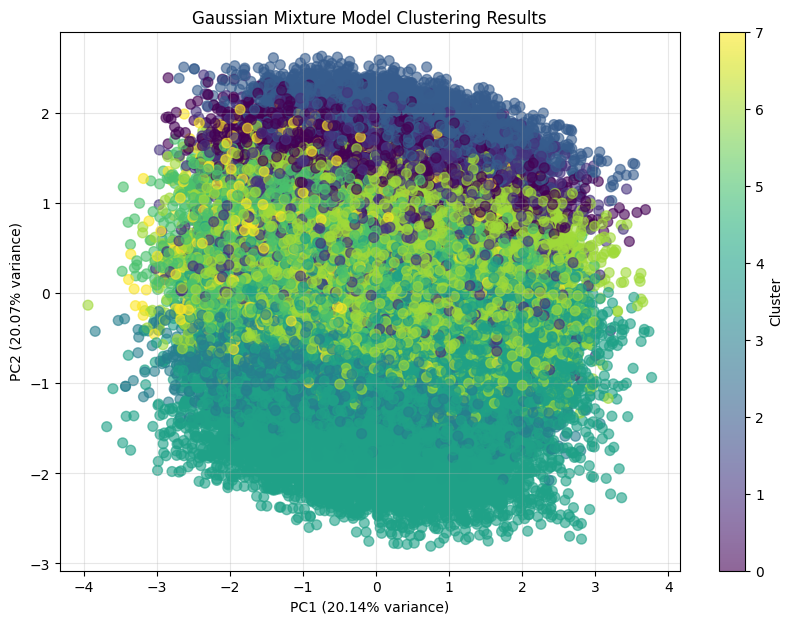

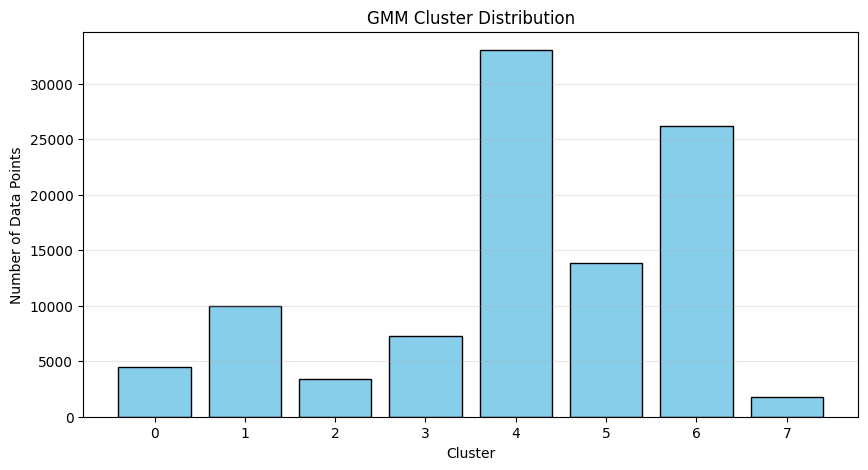


=== Cluster Distribution ===
Cluster 0: 4495 samples (4.49%)
Cluster 1: 9995 samples (9.99%)
Cluster 2: 3371 samples (3.37%)
Cluster 3: 7307 samples (7.31%)
Cluster 4: 33050 samples (33.05%)
Cluster 5: 13850 samples (13.85%)
Cluster 6: 26166 samples (26.17%)
Cluster 7: 1768 samples (1.77%)


In [ ]:
# 7a. PCA Visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, 
                     cmap='viridis', s=50, alpha=0.6)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Gaussian Mixture Model Clustering Results')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()
# 7b. Cluster Distribution
unique, counts = np.unique(cluster_labels, return_counts=True)

In [ ]:
# Add cluster labels to a copy of the dataframe to avoid modifying original X
end_time = time.time()
execution_time = end_time - start_time
n_clusters = len(unique)
sample_idx = np.random.choice(len(X), size=min(10000, len(X)), replace=False)
if n_clusters < 2:
    sil_score = None
    db_score = None
else:
    sil_score = silhouette_score(X.iloc[sample_idx], cluster_labels[sample_idx])
    db_score = davies_bouldin_score(X, cluster_labels)
# Print summary metrics
print(f'Number of Clusters: {n_clusters}')
if sil_score is not None:
    print(f'Silhouette Score: {sil_score:.4f}')
    print(f'Davies-Bouldin Score: {db_score:.4f}')
else:
    print('Silhouette Score: N/A')
    print('Davies-Bouldin Score: N/A')
for cluster, count in zip(unique, counts):
    print(f'Cluster {cluster}: {count} samples ({count/len(X)*100:.2f}%)')
print(f'Execution Time: {execution_time:.2f} seconds')
X_with_labels = X.copy()
X_with_labels['Cluster'] = cluster_labels

# Add probability scores (soft clustering) to the copy only
proba = gmm_final.predict_proba(X)
for i in range(optimal_n):
    X_with_labels[f'Cluster_{i}_Probability'] = proba[:, i]

# Save to CSV from the copy, not the original X
X_with_labels.to_csv('gmm_results.csv', index=False)


✓ Results saved to gmm_results.csv


GAUSSIAN MIXTURE MODEL CLUSTERING SUMMARY
Covariance Type (Auto-selected): diag
Optimal Components (Auto-selected): 8
Silhouette Score: 0.0381
Davies-Bouldin Score: 2.8503
BIC Score: 84304.69
AIC Score: 83477.06
Model Converged: True
